In [23]:
#Importing libraries 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import os 
import sys
from datetime import datetime

print("Libraries imported successfully!")
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Run started: 2026-03-29 16:09:25


In [3]:
#Getting the project root path 
BASE_DIR = os.path.dirname(os.getcwd())
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DATA_DIR = os.path.join(DATA_DIR, "raw/ml-latest")
PROCESSED_DATA_DIR = os.path.join(DATA_DIR, "processed")


In [4]:
#Loading the data 
movies_data = pd.read_csv(os.path.join(RAW_DATA_DIR, "movies.csv"))
rating_data = pd.read_csv(os.path.join(RAW_DATA_DIR, "ratings.csv"))
link_data = pd.read_csv(os.path.join(RAW_DATA_DIR, "links.csv"))
tag_data= pd.read_csv(os.path.join(RAW_DATA_DIR, "tags.csv"))
genome_tags = pd.read_csv(os.path.join(RAW_DATA_DIR, "genome-tags.csv"))
genome_scores = pd.read_csv(os.path.join(RAW_DATA_DIR, "genome-scores.csv"))


In [5]:
#Creating a dict of datasets for easy processing and analysis
dataset_dict = {
    "movies": movies_data,
    "ratings": rating_data,
    "links": link_data,
    "tags": tag_data,
    "genome_tags": genome_tags,
    "genome_scores": genome_scores
}

In [6]:
#shape of data
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("="*50)
    print(f"Shape of {dataset_name} data: {dataset.shape}")
    print("="*50)




Shape of movies data: (86537, 3)


Shape of ratings data: (33832162, 4)


Shape of links data: (86537, 3)


Shape of tags data: (2328315, 4)


Shape of genome_tags data: (1128, 2)


Shape of genome_scores data: (18472128, 3)


In [7]:
#checking for null values 
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("-"*80)
    print(f"Null values in {dataset_name} data \n", dataset.isnull().sum())
    print("\n")
    print("-"*80)



--------------------------------------------------------------------------------
Null values in movies data 
 movieId    0
title      0
genres     0
dtype: int64


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Null values in ratings data 
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Null values in links data 
 movieId      0
imdbId       0
tmdbId     126
dtype: int64


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Null values in tags data 
 userId        0
movieId       0
tag          17
timestamp     0
dtype: int64


-------------------------------------------

Conclusion -> 
 - 126 null values in link data in tmdbId columns
 - 17 null values in tag data in tag columns

Since the number is quite low when compared to total datapoints so they can be removed or either filled with mode value for tag data and tmdb id

**Handling Strategy**
- Missing tmdbId values do not significantly impact our recommendation engine as it is a column which is used while linking the current dataset with external movies databases
- As the number 17 is quite low when compared with number of data point tags data holding which is ``2328315`` so its better to drop it rather than using mode.

In [24]:
#Information about data
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("="*50)
    print(f"Information about {dataset_name} data:")
    print("="*50)
    print(dataset.info())



Information about movies data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   movieId     86537 non-null  int64 
 1   title       86537 non-null  object
 2   genres      86537 non-null  object
 3   genre_list  86537 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.6+ MB
None


Information about ratings data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   userId     int64         
 1   movieId    int64         
 2   rating     float64       
 3   timestamp  int64         
 4   datetime   datetime64[ns]
 5   year       int32         
 6   month      int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(3)
memory usage: 1.5 GB
None


Information about links data:
<class 'pandas.core.f

In [9]:
#description of data
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("-"*80)
    print(f"Description of {dataset_name} data \n", dataset.describe())
    print("\n")
    print("-"*80)



--------------------------------------------------------------------------------
Description of movies data 
              movieId
count   86537.000000
mean   155932.817096
std     78037.145347
min         1.000000
25%    111443.000000
50%    164574.000000
75%    211225.000000
max    288983.000000


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Description of ratings data 
              userId       movieId        rating     timestamp
count  3.383216e+07  3.383216e+07  3.383216e+07  3.383216e+07
mean   1.654380e+05  2.831348e+04  3.542540e+00  1.269362e+09
std    9.534122e+04  4.992865e+04  1.063959e+00  2.541023e+08
min    1.000000e+00  1.000000e+00  5.000000e-01  7.896520e+08
25%    8.295300e+04  1.219000e+03  3.000000e+00  1.046718e+09
50%    1.661290e+05  3.263000e+03  4.000000e+00  1.264740e+09
75%    2.474500e+05  4.049100e+04  4.000000e+00  1.496919e+09
max    

* Timestamp of the ratings data is in object format , which need to be in format of datetime but it is manageable as it not gonna distort the model any how.
* tmdbID datatype by default is float which must be converted to int

In [10]:
#checking for duplicates
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("-"*80)
    print(f"Number of duplicate rows in {dataset_name} data: {dataset.duplicated().sum()}")
    print("\n")
    print("-"*80)



--------------------------------------------------------------------------------
Number of duplicate rows in movies data: 0


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Number of duplicate rows in ratings data: 0


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Number of duplicate rows in links data: 0


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Number of duplicate rows in tags data: 0


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
Number of duplicate rows in genome_tags data: 0


---------------------------------

In [ ]:
#Information about data and memory usage
total_memory_usage = 0
for dataset_name, dataset in dataset_dict.items():
    print("\n")
    print("-"*80)
    print(f"Information about {dataset_name} data \n", dataset.info())
    print("\n")
    total_memory_usage+= dataset.memory_usage(deep=True).sum()
    print("-"*80)



--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB
Information about movies data 
 None


--------------------------------------------------------------------------------


--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB
Information about ratings data 
 None


-----------------------

In [12]:
#print total memory usage of all datasets
print(f"Total memory usage of all datasets: {total_memory_usage} bytes")
#in megabytes
print(f"Total memory usage of all datasets: {total_memory_usage/1024/1024} MB")


Total memory usage of all datasets: 1775426401 bytes
Total memory usage of all datasets: 1693.1785593032837 MB


- The dataset is consuming about 1.69gb of RAM which is high. to reduce the memory consumption figure we can reduce the size of the each value from float64/int64 to float32/int32 or float16/int16
- This large memory can crash the system


In [13]:
n_users  = rating_data['userId'].nunique()
n_movies = rating_data['movieId'].nunique()
n_ratings = len(rating_data)

print(f"Total users      : {n_users:,}")
print(f"Total movies     : {n_movies:,}")
print(f"Total ratings    : {n_ratings:,}")
print(f"Avg ratings/user : {n_ratings / n_users:.1f}")
print(f"Avg ratings/movie: {n_ratings / n_movies:.1f}")
print()

Total users      : 330,975
Total movies     : 83,239
Total ratings    : 33,832,162
Avg ratings/user : 102.2
Avg ratings/movie: 406.4



### Sparsity Analysis

In [14]:
#Sparsity 
sparsity = 1 - (n_ratings/(n_movies * n_users))

print("Sparsity of Dataset:", sparsity)
possible = n_movies * n_users
print(f"Matrix size      : {n_users:,} x {n_movies:,} = {possible:,}")

Sparsity of Dataset: 0.9987719735903972
Matrix size      : 330,975 x 83,239 = 27,550,028,025


Sparsity analysis is done during EDA to understand how many possible user–movie interactions actually exist in the dataset.  
In recommender systems, users usually rate only a small number of movies, so most entries in the user–item matrix remain empty.

By calculating sparsity, we can understand how sparse the dataset is and what challenges it may create for recommendation algorithms.  
High sparsity can make it harder to compute similarities between users or items, which directly affects collaborative filtering models.

In this dataset, the sparsity is **0.99877 (~99.88%)**, which means that almost all possible user–movie interactions are missing.  
This level of sparsity is common in real-world recommendation datasets and is expected when the number of users and items is very large.

### Distribution plots

In [15]:
##Setup for plots
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("husl")

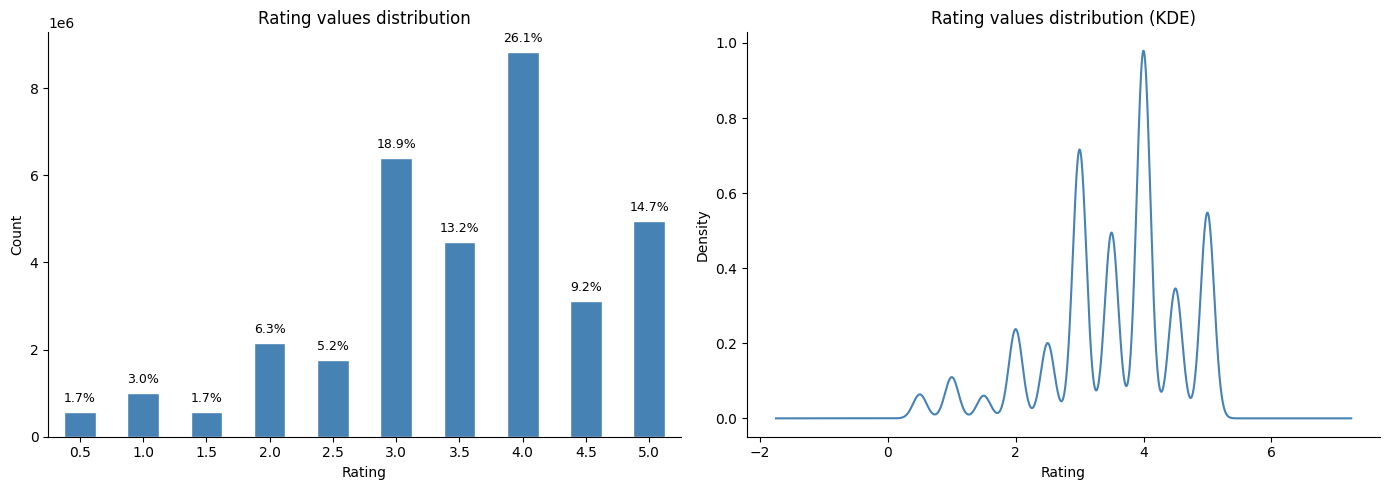


 Mean of ratings: 3.543

 Median of ratings: 4.000

 Standard deviation of ratings: 1.064


In [16]:
## Rating distribution

fig, axes = plt.subplots(1, 2, figsize=(14,5))

#Distribution of rating values
rating_data['rating'].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Rating values distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)

#Add percentage labels on the tops of the bars
total = len(rating_data)
for p in axes[0].patches:                              #Loops over each bar in the chart
    percentage = f"{100 * p.get_height() / total:.1f}%"
    axes[0].annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 5), textcoords='offset points')

#rating distribution as kde
rating_data['rating'].sample(100000).plot(kind="kde", ax=axes[1], color="steelblue")   # Sample is used to speed up the plot, as the dataset is large.
axes[1].set_title("Rating values distribution (KDE)")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Density")

plt.tight_layout()
folder = "paths"
os.makedirs(os.path.join(PROCESSED_DATA_DIR, "plots"), exist_ok=True)
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/01_rating_distribution.png"), dpi=150 , bbox_inches="tight",)
plt.show()

print(f"\n Mean of ratings: {rating_data['rating'].mean():.3f}")
print(f"\n Median of ratings: {rating_data['rating'].median():.3f}")
print(f"\n Standard deviation of ratings: {rating_data['rating'].std():.3f}")

<u>**Observation**</u>  - Rating Distribution

The rating distribution shows that most users tend to give higher ratings.

- The majority of ratings lie between **3.0 and 5.0**
- **4.0 is the most frequently given rating**
- Very few users give low ratings (below 2.0)
- The distribution is **slightly left-skewed**, indicating a positive bias in user ratings

<u>**Statistical Summary**</u>

- **Mean Rating:** 3.543  
- **Median Rating:** 4.000  
- **Standard Deviation:** 1.064  

Overall, users generally rate movies positively, which is a common trend in real-world recommendation datasets.



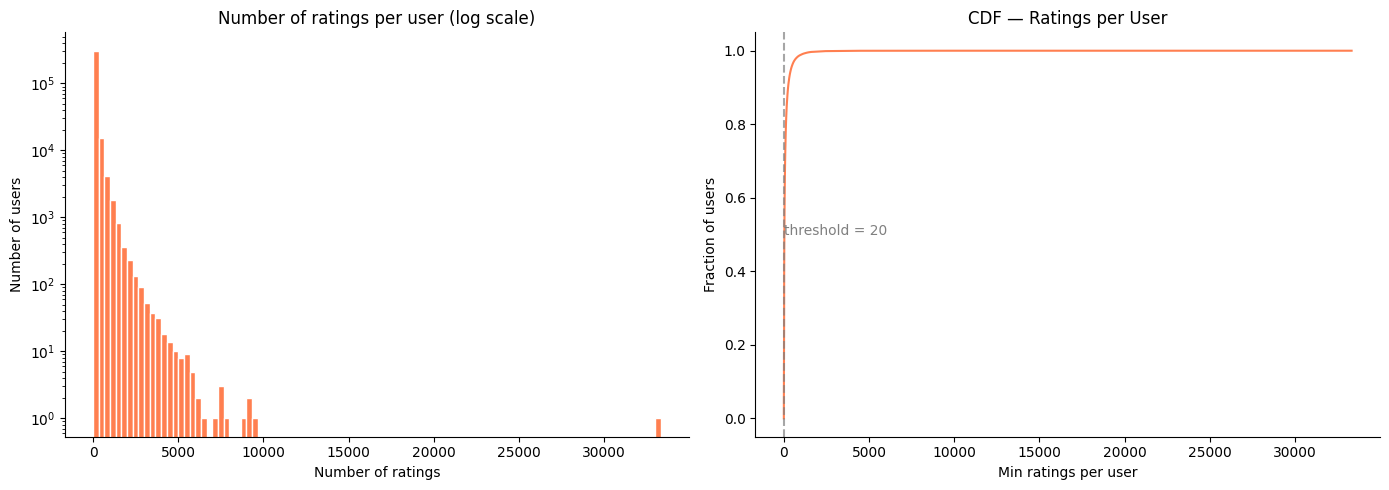


Min ratings/user    : 1
Max ratings/user    : 33332
Median ratings/user : 31
Users with < 20     : 126,532 (38.2%)
Users with < 5      : 23,562 (7.1%)


In [ ]:
# Rating per user distribution
rating_per_user = rating_data.groupby('userId').size()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(rating_per_user, bins=100, color="coral", edgecolor= "white", log=True)
axes[0].set_title("Number of ratings per user (log scale)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of users")
axes[0].tick_params(axis='x', rotation=0)

#cumulative distribution of ratings per user  , it answers the question "What fraction of users have ≤ X ratings?"
sorted_counts = np.sort(rating_per_user)   
cdf = np.arange(1, len(sorted_counts)+1) / len(sorted_counts)
axes[1].plot(sorted_counts, cdf, color='coral')
axes[1].set_title('CDF — Ratings per User')
axes[1].set_xlabel('Min ratings per user')
axes[1].set_ylabel('Fraction of users')
axes[1].axvline(x=20, color='gray', linestyle='--', alpha=0.7)
axes[1].text(22, 0.5, 'threshold = 20', fontsize=10, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/02_ratings_per_user.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMin ratings/user    : {rating_per_user.min()}")
print(f"Max ratings/user    : {rating_per_user.max()}")
print(f"Median ratings/user : {rating_per_user.median():.0f}")
print(f"Users with < 20     : {(rating_per_user < 20).sum():,} "
      f"({100*(rating_per_user < 20).mean():.1f}%)")
print(f"Users with < 5      : {(rating_per_user < 5).sum():,} "
      f"({100*(rating_per_user < 5).mean():.1f}%)")

**<u>Ratings per User Analysis</u>**

This analysis shows how active users are in terms of the number of ratings they provide.

**<u>Key Observations</u>**

- Most users have given **very few ratings**, while a small number of users are highly active
- The distribution is **heavily right-skewed (long tail)**  
  → meaning a few users have extremely high activity (up to 33,332 ratings)
- The **median number of ratings per user is 31**, indicating that half of the users have rated fewer than 31 movies

**<u>User Activity Insights</u>**

- **38.2% of users** have given fewer than **20 ratings**
- **7.1% of users** have given fewer than **5 ratings**
- Minimum ratings by a user: **1**
- Maximum ratings by a user: **33,332**

**<u>Understanding the Plots</u>**

- **Histogram (log scale):**  
  Shows that most users are clustered at low activity levels, while a few users contribute a very large number of ratings

- **CDF Curve:**  
  The steep rise at the beginning indicates that a large fraction of users have very few ratings  
  The vertical line at **20 ratings** highlights a possible threshold for filtering less active users

**<u>Insight</u>**

This imbalance suggests that the dataset contains many **low-activity users**, which can introduce noise in collaborative filtering models.  
Filtering out users with very few ratings (e.g., less than 20) can help improve model quality and recommendation reliability.

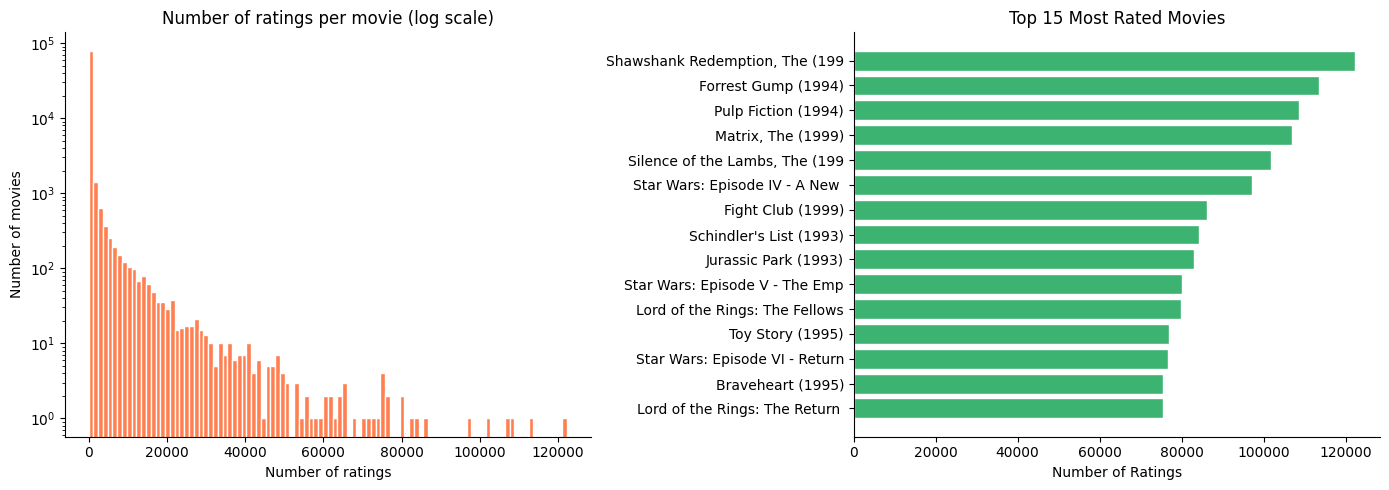


Movies with < 10 ratings : 51,218 (61.5%)
Movies with < 5  ratings : 39,366


In [18]:
#Rating per movies distribution
rating_per_movie = rating_data.groupby('movieId').size()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(rating_per_movie, bins=100, color="coral", edgecolor= "white", log=True)
axes[0].set_title("Number of ratings per movie (log scale)")
axes[0].set_xlabel("Number of ratings")
axes[0].set_ylabel("Number of movies")
axes[0].tick_params(axis='x', rotation=0)

# Top 20 most rated movies
top_movies = (rating_data.groupby('movieId')
              .size()
              .reset_index(name='count')
              .merge(movies_data[['movieId','title']], on='movieId')
              .nlargest(15, 'count'))

axes[1].barh(top_movies['title'].str[:30],
             top_movies['count'],
             color='mediumseagreen', edgecolor='white')
axes[1].set_title('Top 15 Most Rated Movies')
axes[1].set_xlabel('Number of Ratings')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/03_ratings_per_movie.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMovies with < 10 ratings : {(rating_per_movie < 10).sum():,} "
      f"({100*(rating_per_movie < 10).mean():.1f}%)")
print(f"Movies with < 5  ratings : {(rating_per_movie < 5).sum():,}")

**<u>Ratings per Movie Analysis</u>**

This analysis explores how many ratings each movie receives and identifies the most popular movies in the dataset.

**<u>Key Observations</u>**

- The distribution is **highly right-skewed (long tail)**  
  → Most movies have very few ratings, while a few movies receive a very large number of ratings

- A large portion of movies have very low engagement:
  - **61.5% of movies** have fewer than **10 ratings**
  - **39,366 movies** have fewer than **5 ratings**

- Only a small number of movies are highly popular and dominate user interactions

**<u>Top Rated Movies (by count)</u>**

- *The Shawshank Redemption (1994)* has the highest number of ratings  
- Other highly rated movies include:
  - *Forrest Gump (1994)*
  - *Pulp Fiction (1994)*
  - *The Matrix (1999)*
  - *The Silence of the Lambs (1991)*

These movies are widely popular and frequently rated by users.

**<u>Understanding the Plots</u>**

- **Histogram (log scale):**  
  Shows that most movies fall into the low-rating count region, with very few movies having extremely high counts

- **Bar chart (Top 15 movies):**  
  Highlights the most popular movies based on number of ratings

**<u>Insight</u>**

This imbalance indicates a **popularity bias**, where a small number of movies dominate interactions.  
Filtering out movies with very few ratings can improve recommendation quality and reduce noise in collaborative filtering models.

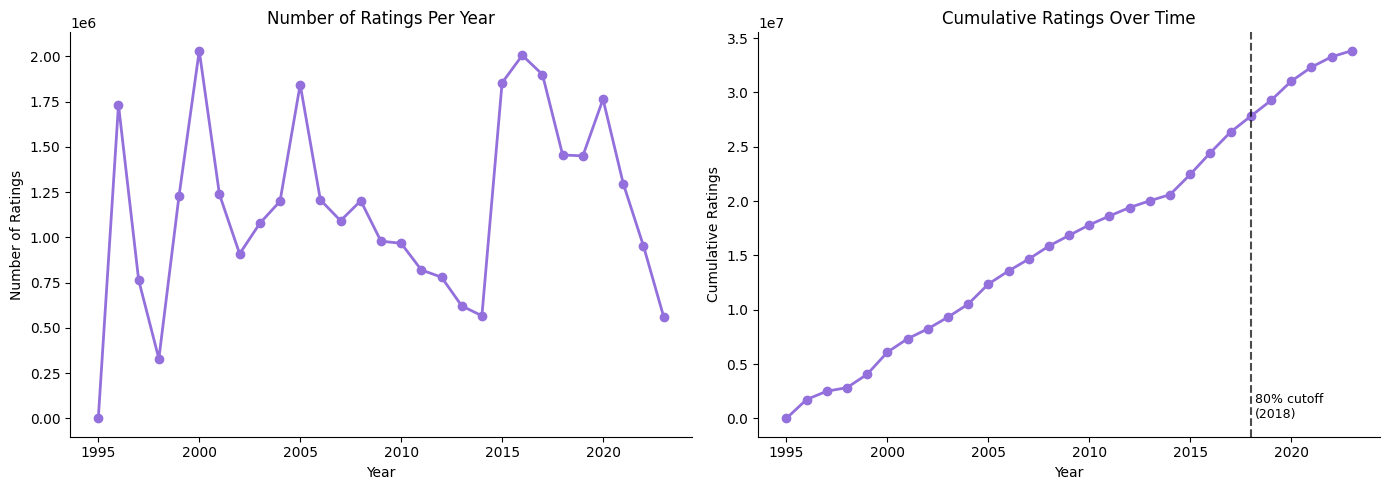


Earliest rating : 1995-01-09 11:46:44
Latest rating   : 2023-07-20 08:53:33
Date range      : 10418 days

80% of ratings occur before year: 2018


In [35]:
# Convert timestamp to datetime
rating_data['datetime'] = pd.to_datetime(rating_data['timestamp'], unit='s')
rating_data['year'] = rating_data['datetime'].dt.year
rating_data['month'] = rating_data['datetime'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ratings over time
rating_data.groupby('year').size().plot(
    ax=axes[0], color='mediumpurple', marker='o', linewidth=2
)
axes[0].set_title('Number of Ratings Per Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Ratings')

# Cumulative ratings over time
cumulative = rating_data.groupby('year').size().cumsum()
cumulative.plot(ax=axes[1], color='mediumpurple',
                marker='o', linewidth=2)
axes[1].set_title('Cumulative Ratings Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Cumulative Ratings')

# Mark the 80% point
total_ratings = len(rating_data)
cutoff_idx = (cumulative >= total_ratings * 0.8).idxmax()
axes[1].axvline(x=cutoff_idx, color='black',
                linestyle='--', alpha=0.7)
axes[1].text(cutoff_idx+0.2, cumulative.min(),
             f'80% cutoff\n({cutoff_idx})',
             fontsize=9, color='black')

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/04_ratings_over_time.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nEarliest rating : {rating_data['datetime'].min()}")
print(f"Latest rating   : {rating_data['datetime'].max()}")
print(f"Date range      : {(rating_data['datetime'].max() - rating_data['datetime'].min()).days} days")
print(f"\n80% of ratings occur before year: {cutoff_idx}")

**<u>Ratings Over Time Analysis</u>**

This analysis examines how user activity has evolved over time based on rating timestamps.

**<u>Key Observations</u>**

- Ratings start from **1995** and continue up to **2023**, covering a span of **~28 years**
- User activity increases significantly after the early years, with noticeable growth in the 2000s
- Peak activity occurs around **2015–2018**, where the number of ratings is highest
- After 2018, there is a slight decline in yearly ratings

**<u>Cumulative Growth</u>**

- The cumulative ratings curve shows a steady and consistent increase over time
- **80% of all ratings were generated before 2018**, indicating that most user activity is concentrated in earlier years

**<u>Insights</u>**

- The dataset is **time-skewed**, with a large portion of interactions coming from earlier periods
- Recent years have relatively fewer ratings, which may affect:
  - model generalization
  - trend-based recommendations

**<u>Dataset Range</u>**

- **Earliest Rating:** 1995-01-09  
- **Latest Rating:** 2023-07-20  
- **Total Duration:** 10,418 days  

**<u>Implication</u>**

Since most data is concentrated before 2018, it may be useful to:
- apply **time-based splitting** for training/testing  
- or give more weight to **recent interactions** in advanced models

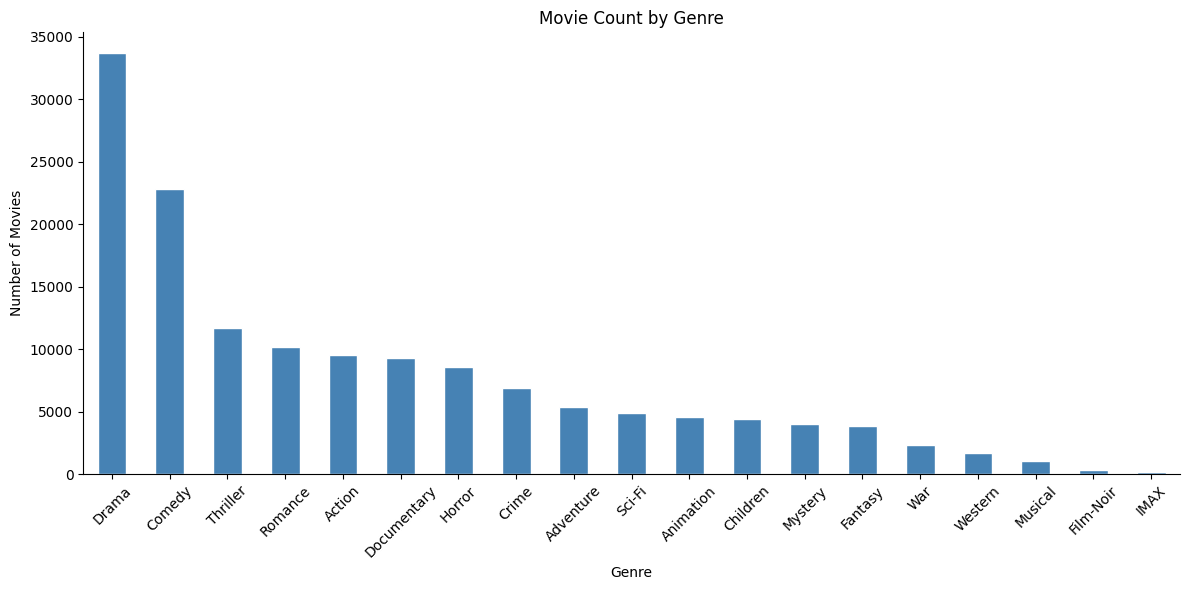


Unique genres       : 19
Top genre           : Drama (33,681 movies)
Movies with no genre: 7060


In [20]:
# Explode genres (each movie has multiple)
movies_data['genre_list'] = movies_data['genres'].str.split('|')
genre_counts = (movies_data.explode('genre_list')
                ['genre_list']
                .value_counts()
                .drop('(no genres listed)', errors='ignore'))

fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.plot(kind='bar', ax=ax,
                  color='steelblue', edgecolor='white')
ax.set_title('Movie Count by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Movies')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/05_genre_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nUnique genres       : {genre_counts.shape[0]}")
print(f"Top genre           : {genre_counts.index[0]} ({genre_counts.iloc[0]:,} movies)")
print(f"Movies with no genre: {(movies_data['genres'] == '(no genres listed)').sum()}")

**<u>Movie Genre Distribution</u>**

This analysis explores how movies are distributed across different genres in the dataset.

**<u>Key Observations</u>**

- There are **19 unique genres** in the dataset
- **Drama** is the most common genre with **33,681 movies**, followed by **Comedy**
- Genres like **Thriller, Romance, and Action** also have a strong presence
- Less common genres include **IMAX, Film-Noir, and Musical**

**<u>Distribution Insights</u>**

- The dataset is **highly imbalanced across genres**
- A few genres (like Drama and Comedy) dominate the dataset
- Many genres have significantly fewer movies, indicating **long-tail distribution**

**<u>Missing Genre Information</u>**

- **7,060 movies** have no genre listed (`(no genres listed)`)
- These entries may need to be:
  - removed  
  - or handled separately during modeling

**<u>Insights</u>**

- The dominance of certain genres may introduce **bias in recommendations**
- Less represented genres might get **less visibility** in collaborative filtering models
- This distribution is important for building **genre-aware or hybrid recommender systems**

Total tags          : 2,328,298
Unique tags         : 153,949
Movies with tags    : 53,452
% movies with tags  : 64.2%

Top 20 tags:
tag
sci-fi                14892
atmospheric           12776
action                11747
comedy                10966
funny                  9851
surreal                9443
visually appealing     9086
twist ending           8428
dark comedy            7777
thought-provoking      7731
based on a book        7718
romance                7123
dystopia               7056
cinematography         6645
fantasy                6469
social commentary      6425
violence               6377
stylized               6201
classic                6182
quirky                 6181


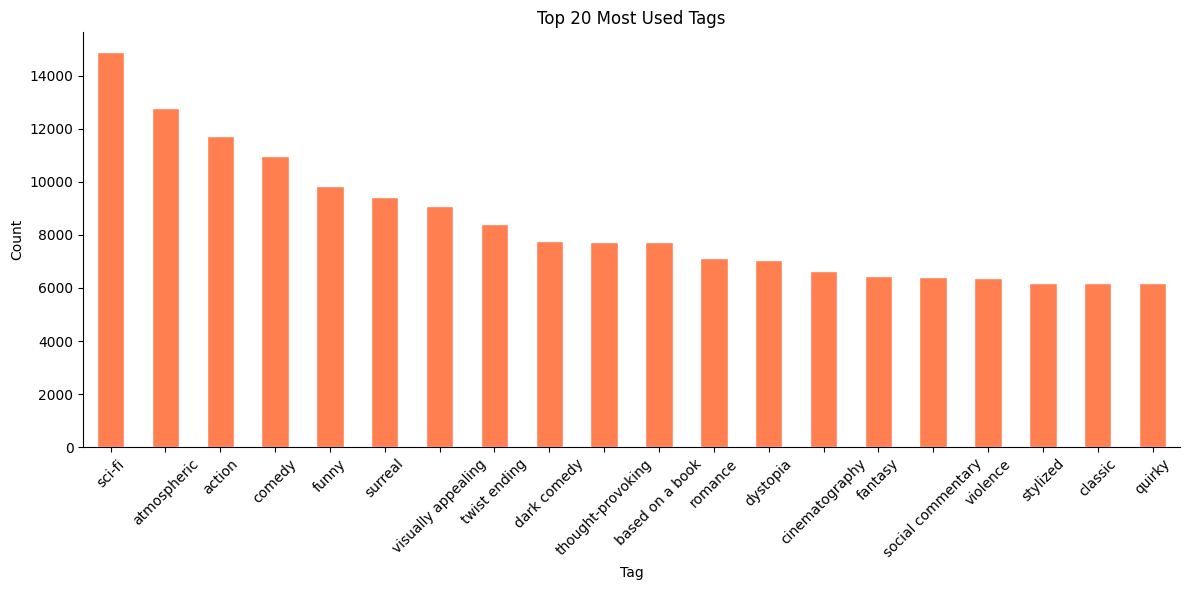

In [21]:
# Tags are our richest content feature
print(f"Total tags          : {len(tag_data):,}")
print(f"Unique tags         : {tag_data['tag'].nunique():,}")
print(f"Movies with tags    : {tag_data['movieId'].nunique():,}")
print(f"% movies with tags  : {100 * tag_data['movieId'].nunique() / n_movies:.1f}%")
print()

# Top tags
top_tags = tag_data['tag'].str.lower().value_counts().head(20)
print("Top 20 tags:")
print(top_tags.to_string())

fig, ax = plt.subplots(figsize=(12, 6))
top_tags.plot(kind='bar', ax=ax,
              color='coral', edgecolor='white')
ax.set_title('Top 20 Most Used Tags')
ax.set_xlabel('Tag')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/06_top_tags.png"), dpi=150, bbox_inches='tight')
plt.show()

**<u>Tag Analysis</u>**

Tags provide rich, user-generated metadata that can capture deeper characteristics of movies beyond genres.

**<u>Key Statistics</u>**

- **Total Tags:** 2,328,298  
- **Unique Tags:** 153,949  
- **Movies with Tags:** 53,452  
- **Coverage:** 64.2% of movies have at least one tag  

**<u>Top Tags</u>**

The most frequently used tags include:

- **sci-fi**, **atmospheric**, **action**, **comedy**, **funny**
- Other common tags: **surreal**, **visually appealing**, **twist ending**, **dark comedy**, **thought-provoking**

**<u>Observations</u>**

- Tags are highly diverse (**150K+ unique tags**), showing rich user expression
- A small number of tags are used very frequently, while most tags are rare → **long-tail distribution**
- Many tags describe:
  - **mood** (atmospheric, dark, surreal)  
  - **themes** (dystopia, social commentary)  
  - **style** (cinematography, stylized)  

**<u>Insights</u>**

- Tags are more expressive than genres and can capture **fine-grained user preferences**
- They are highly useful for:
  - **content-based filtering**
  - **hybrid recommender systems**
- However, due to high variability, tags may require:
  - normalization (lowercasing, cleaning)  
  - filtering of rare tags  

**<u>Note</u>**

Since not all movies have tags, this feature may introduce **missing data challenges** and should be handled carefully during modeling.

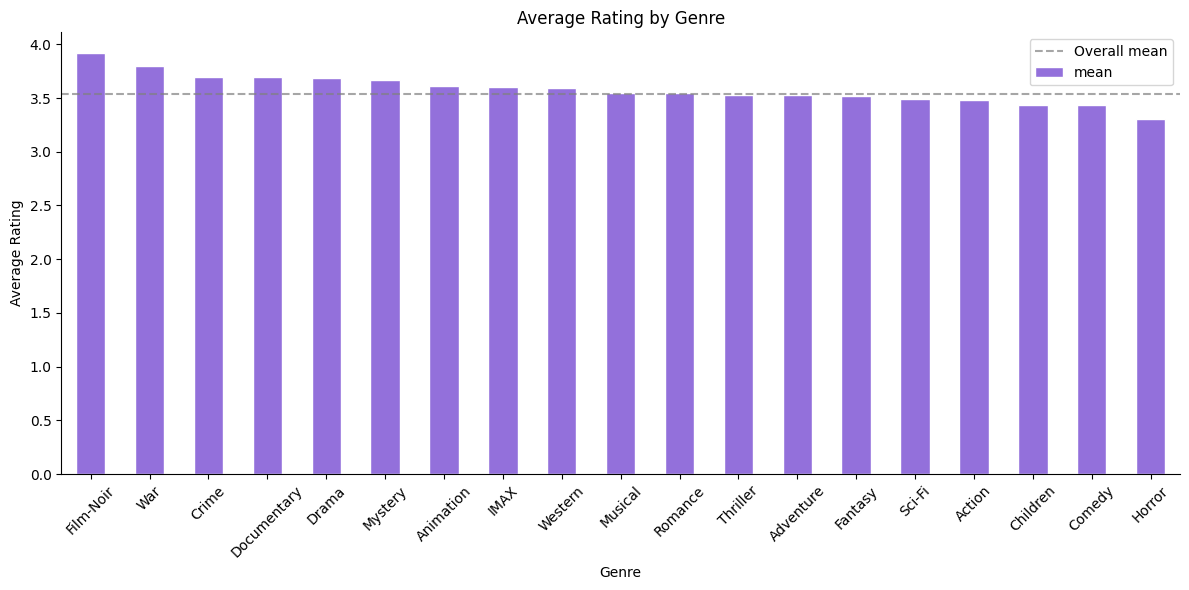

In [22]:
# Merge ratings with movies for genre-level analysis
rating  = rating_data.sample(frac=0.3, random_state=42)    #Data is heavy so we take a sample for faster processing and plotting. This is just for EDA, not for modeling.
ratings_movies = rating.merge(movies_data[['movieId','genres']], on='movieId')
ratings_movies['genre_list'] = ratings_movies['genres'].str.split('|')
ratings_exploded = ratings_movies.explode('genre_list')
ratings_exploded = ratings_exploded[
    ratings_exploded['genre_list'] != '(no genres listed)'
]

genre_stats = (ratings_exploded.groupby('genre_list')['rating']
               .agg(['mean', 'count'])
               .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(12, 6))
genre_stats['mean'].plot(kind='bar', ax=ax,
                         color='mediumpurple', edgecolor='white')
ax.set_title('Average Rating by Genre')
ax.set_xlabel('Genre')
ax.set_ylabel('Average Rating')
ax.axhline(y=rating['rating'].mean(), color='gray',
           linestyle='--', alpha=0.7, label='Overall mean')
ax.legend()
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DATA_DIR, "plots/07_avg_rating_genre.png"), dpi=150, bbox_inches='tight')
plt.show()

**<u>Average Rating by Genre</u>**

This analysis compares the average ratings across different movie genres.

**<u>Key Observations</u>**

- **Film-Noir** has the highest average rating (~3.9), followed by **War** and **Crime**
- Most genres fall in a close range between **3.4 and 3.8**
- **Horror** has the lowest average rating (~3.3)

**<u>Comparison with Overall Average</u>**

- The overall average rating is around **3.54**
- Genres like **Film-Noir, War, Crime, and Drama** are above average
- Genres like **Comedy, Action, and Horror** fall slightly below average

**<u>Insight</u>**

Users tend to rate **serious and story-driven genres** higher, while more entertainment-focused genres show slightly lower average ratings.  
However, the variation across genres is relatively small, indicating **consistent rating behavior overall**.

**<u>Note</u>**

A **30% sample of the dataset** was used for this analysis to reduce memory usage and improve performance during EDA.

### Final Summary

In [36]:
print("=" * 55)
print("EDA FINDINGS → PREPROCESSING DECISIONS")
print("=" * 55)
print()
print("Finding                    Decision")
print("-" * 55)
print("Rating skew positive    →  BPR loss, not MSE")
print("99.88% sparse matrix    →  Negative sampling")
print("38.2% users < 20 ratings→  Filter threshold = 20")
print("61.5% movies < 10 ratings→ Filter threshold = 10")
print("Time-skewed (80% < 2018)→  Time-based split")
print("64.2% movies have tags  →  Handle missing gracefully")
print("7,060 no-genre movies   →  Exclude from content str")
print("Genome scores available →  Use for content tower")

EDA FINDINGS → PREPROCESSING DECISIONS

Finding                    Decision
-------------------------------------------------------
Rating skew positive    →  BPR loss, not MSE
99.88% sparse matrix    →  Negative sampling
38.2% users < 20 ratings→  Filter threshold = 20
61.5% movies < 10 ratings→ Filter threshold = 10
Time-skewed (80% < 2018)→  Time-based split
64.2% movies have tags  →  Handle missing gracefully
7,060 no-genre movies   →  Exclude from content str
Genome scores available →  Use for content tower
